In [6]:
# Smart Agriculture Disease Advisor

## Data Exploration

### Objective
#The goal of this notebook is to explore the PlantVillage dataset, understand the available crop disease classes, visualize sample images, and prepare the dataset for machine learning.

In [21]:
!pip install -q kaggle

In [22]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_ba297b482de1d955171733331c9390f3")

os.chmod("/root/.kaggle/access_token", 0o600)

In [23]:
!kaggle datasets download -d mohitsingh1804/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:42<00:00, 20.4MB/s]



In [24]:
!unzip -q plantvillage.zip -d plantvillage

In [25]:
import os
print(os.listdir("plantvillage"))

['PlantVillage']


In [26]:
print(os.listdir("plantvillage/PlantVillage")[:10])

['val', 'train']


In [27]:
train_path = "plantvillage/PlantVillage/train"
val_path = "plantvillage/PlantVillage/val"

import os

classes = sorted(os.listdir(train_path))

print("Total Classes:", len(classes))
print(classes)

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

In [28]:
for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"{cls}: {count}")

Apple___Apple_scab: 504
Apple___Black_rot: 496
Apple___Cedar_apple_rust: 220
Apple___healthy: 1316
Blueberry___healthy: 1202
Cherry_(including_sour)___Powdery_mildew: 842
Cherry_(including_sour)___healthy: 684
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410
Corn_(maize)___Common_rust_: 953
Corn_(maize)___Northern_Leaf_Blight: 788
Corn_(maize)___healthy: 929
Grape___Black_rot: 944
Grape___Esca_(Black_Measles): 1107
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 861
Grape___healthy: 339
Orange___Haunglongbing_(Citrus_greening): 4405
Peach___Bacterial_spot: 1838
Peach___healthy: 288
Pepper,_bell___Bacterial_spot: 797
Pepper,_bell___healthy: 1183
Potato___Early_blight: 800
Potato___Late_blight: 800
Potato___healthy: 121
Raspberry___healthy: 297
Soybean___healthy: 4072
Squash___Powdery_mildew: 1468
Strawberry___Leaf_scorch: 887
Strawberry___healthy: 364
Tomato___Bacterial_spot: 1702
Tomato___Early_blight: 800
Tomato___Late_blight: 1527
Tomato___Leaf_Mold: 761
Tomato___Septoria_leaf_spo

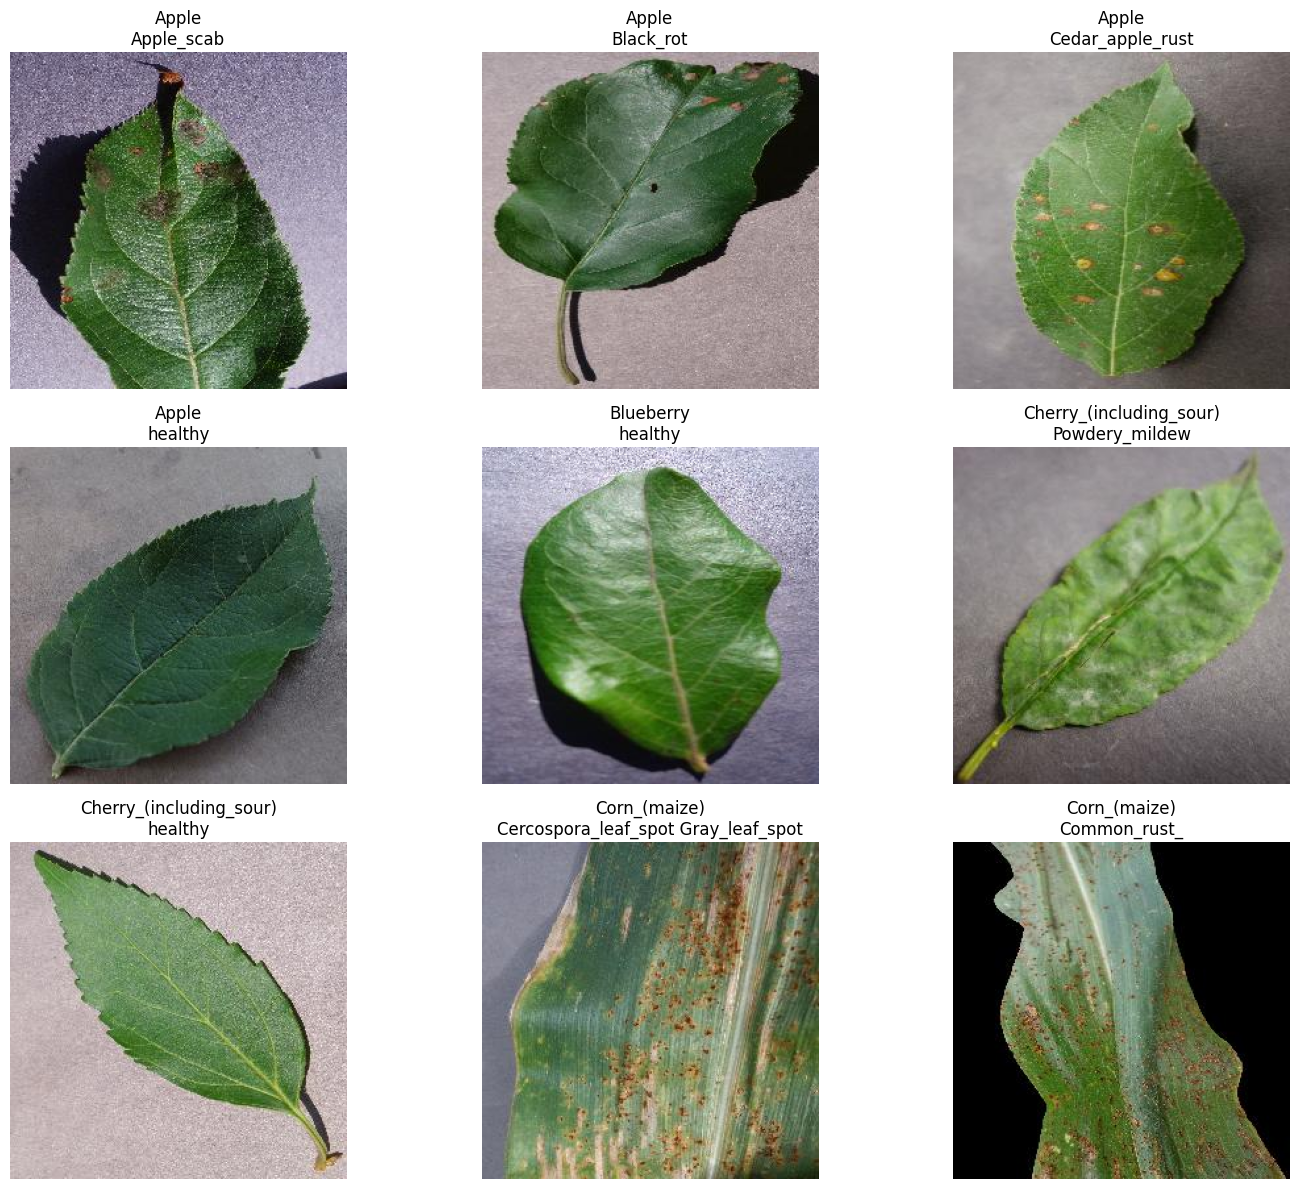

In [29]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15,12))

for i, cls in enumerate(classes[:9]):

    img_name = os.listdir(os.path.join(train_path, cls))[0]

    img_path = os.path.join(train_path, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls.replace("___", "\n"))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
img = Image.open(img_path)
print("Image Size:", img.size)

Image Size: (256, 256)


In [31]:
train_images = 0

for cls in classes:
    train_images += len(os.listdir(os.path.join(train_path, cls)))

val_images = 0

for cls in classes:
    val_images += len(os.listdir(os.path.join(val_path, cls)))

print("Training Images :", train_images)
print("Validation Images :", val_images)
print("Total Images :", train_images + val_images)

Training Images : 43444
Validation Images : 10861
Total Images : 54305


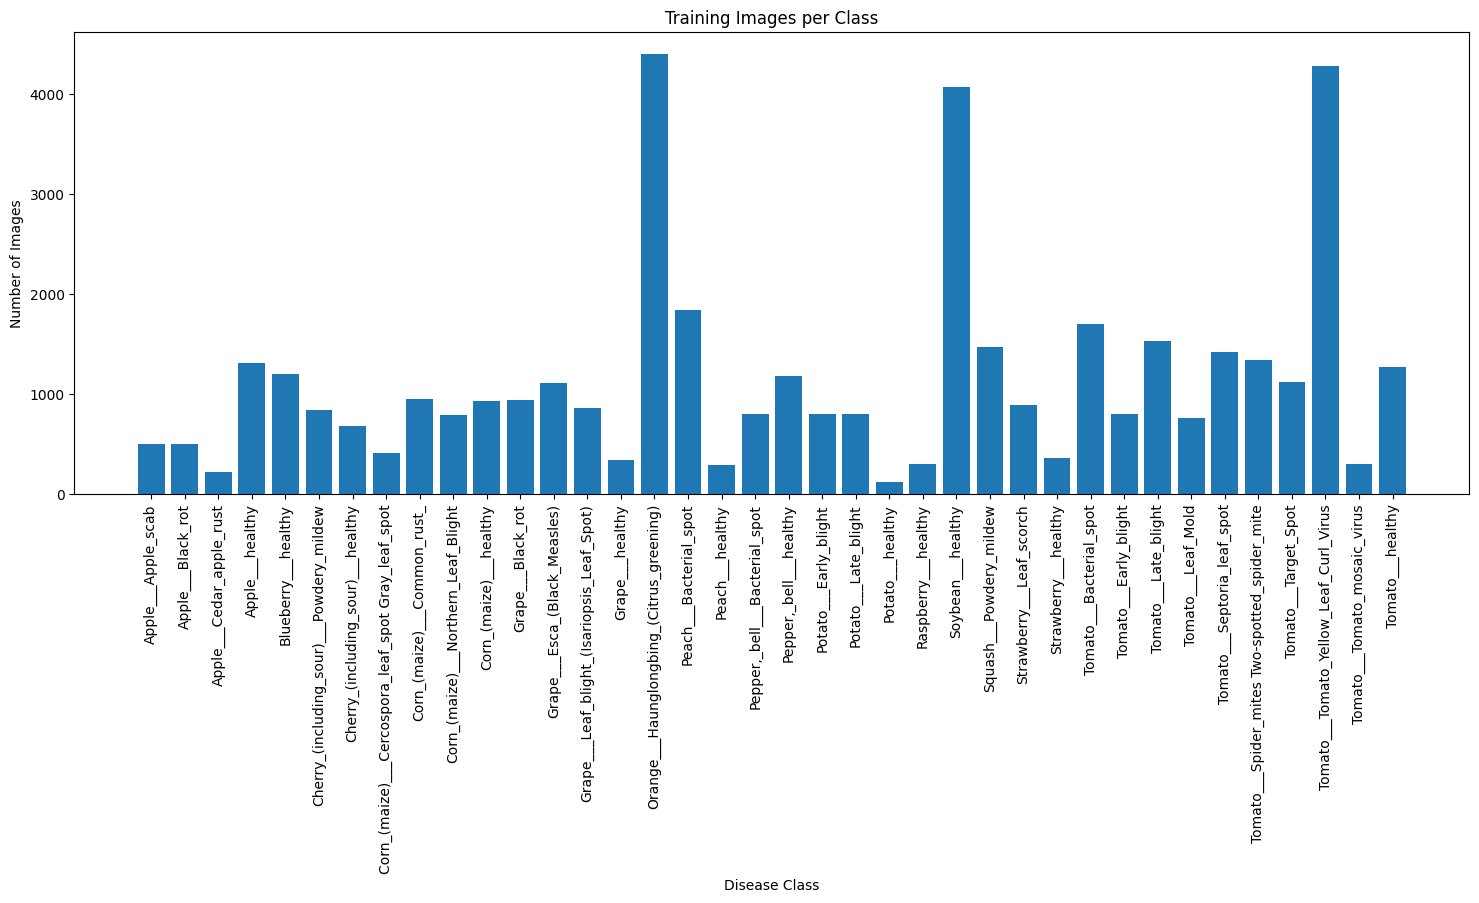

In [32]:
import matplotlib.pyplot as plt

counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in classes]

plt.figure(figsize=(18,6))
plt.bar(range(len(classes)), counts)
plt.xticks(range(len(classes)), classes, rotation=90)
plt.title("Training Images per Class")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.show()